# Fine-tuning — EQCCT

Fine-tunes the EQCCT phase pickers using the shared local dataset and saves the trained weights and loss history. Architecture-specific settings are defined below.


## Key settings

EQCCTP and EQCCTS are fine-tuned separately on 60 s windows with standard-deviation normalization. Each phase output uses a soft arrival target and binary cross-entropy, with dev loss guiding early stopping.

## 1. Environment + shared utilities

In [1]:
import sys
sys.path.insert(0, r"M:\Github\TFM_SeismicPhasePicker_ColombianAndesRegion\src\training")
import training_utils as tu
import torch
import torch.nn.functional as F
import numpy as np
import seisbench.models as sbm
import seisbench.generate as sbg
from torch.utils.data import DataLoader
tu.banner()

seisbench 0.12.3 | torch 2.5.1+cu121 | device: cuda


## 2. Configuration

In [2]:
ARCH       = "EQCCT"
STATIONS   = None
PRETRAINED = "original"
EPOCHS     = 100
BATCH_SIZE = 32
LR         = 1e-4
SIGMA      = 20
SEED       = 42
PATIENCE   = 6
MIN_DELTA  = 1e-4
IN_SAMPLES = 6000

# (SeisBench class, phase label, arrival column)
SPECS = [("EQCCTP", "P", "trace_p_arrival_sample"),
         ("EQCCTS", "S", "trace_s_arrival_sample")]

torch.manual_seed(SEED); np.random.seed(SEED)
print("Stations:", "ALL" if not STATIONS else STATIONS)

Stations: ALL


## 3. Dataset (train / dev)

In [3]:
data = tu.load_dataset(STATIONS)
train, dev, test = data.train_dev_test()
print()
tu.split_summary(train, "train"); tu.split_summary(dev, "dev")
print(f"  (test reserved for evaluate: {len(test)})")

No filter (all stations): 106580 traces
stations: ['BRJC', 'CBOC', 'CHI', 'DBB', 'GUY2C', 'JAMC', 'MAL', 'NOR', 'ORTC', 'PAL', 'PIZC', 'PRA', 'PTB', 'PTGC', 'QUBC', 'RUS', 'SPBC', 'TAM', 'URE', 'URMC', 'YOT', 'ZAR']

  train: 74600  {'earthquake': 37300, 'noise': 37300}
  dev  : 16414  {'earthquake': 8207, 'noise': 8207}
  (test reserved for evaluate: 15566)


## 4. Single-phase training generator (EQCCT-specific)

In [4]:
def make_gen(subset, phase_col, phase_label):
    gen = sbg.GenericGenerator(subset)
    gen.add_augmentations([
        sbg.WindowAroundSample(list(tu.PHASE_DICT.keys()), samples_before=6000,
                               windowlen=12000, selection="random", strategy="variable"),
        sbg.RandomWindow(windowlen=IN_SAMPLES, strategy="pad"),
        sbg.Normalize(demean_axis=-1, amp_norm_axis=-1, amp_norm_type="std"),
        sbg.ChangeDtype(np.float32),
        sbg.ProbabilisticLabeller(label_columns={phase_col: phase_label}, sigma=SIGMA,
                                  dim=0, model_labels=[phase_label]),
    ])
    return gen

def loss_fn(out, batch):
    # EQCCT: output (B, 1, W) sigmoid -> BCE against the phase Gaussian
    y = batch["y"].float()
    if y.shape[1] > 1:        # ProbabilisticLabeller adds a noise channel -> keep the phase (channel 0)
        y = y[:, :1]
    return F.binary_cross_entropy(out.float(), y)   # BCE requires float32 and matching shape
print("helpers ready")

helpers ready


## 5. Fine-tune EQCCTP (P) and EQCCTS (S)


===== EQCCTP  (phase P) =====


c:\Users\moise\miniconda3\envs\tesismaster\Lib\site-packages\seisbench\models\base.py:952: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_weights = torch.load(f"{path_p

X: (32, 3, 6000)  y: (32, 2, 6000)
epoch 01/100   train=0.0067   dev=0.0053  *best dev*
epoch 02/100   train=0.0053   dev=0.0049  *best dev*
epoch 03/100   train=0.0050   dev=0.0047  *best dev*
epoch 04/100   train=0.0048   dev=0.0046  *best dev*
epoch 05/100   train=0.0047   dev=0.0046  (no improvement 1/6)
epoch 06/100   train=0.0046   dev=0.0045  *best dev*
epoch 07/100   train=0.0046   dev=0.0044  (no improvement 1/6)
epoch 08/100   train=0.0046   dev=0.0044  *best dev*
epoch 09/100   train=0.0045   dev=0.0043  (no improvement 1/6)
epoch 10/100   train=0.0045   dev=0.0043  (no improvement 2/6)
epoch 11/100   train=0.0044   dev=0.0043  (no improvement 3/6)
epoch 12/100   train=0.0044   dev=0.0043  (no improvement 4/6)
epoch 13/100   train=0.0044   dev=0.0043  *best dev*
epoch 14/100   train=0.0044   dev=0.0043  (no improvement 1/6)
epoch 15/100   train=0.0044   dev=0.0043  (no improvement 2/6)
epoch 16/100   train=0.0043   dev=0.0042  (no improvement 3/6)
epoch 17/100   train=0.0043

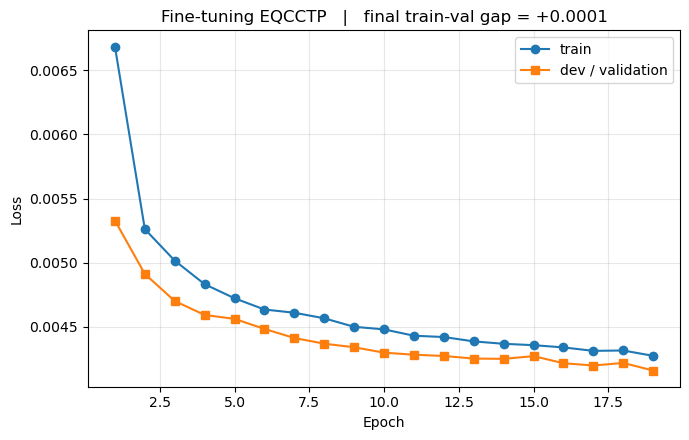

[OK] No sign of overfitting (best dev at epoch 19/19, final gap +0.0001).
saved eqcctp_ft.pt

===== EQCCTS  (phase S) =====


c:\Users\moise\miniconda3\envs\tesismaster\Lib\site-packages\seisbench\models\base.py:952: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_weights = torch.load(f"{path_p

X: (32, 3, 6000)  y: (32, 2, 6000)
epoch 01/100   train=0.0061   dev=0.0051  *best dev*
epoch 02/100   train=0.0050   dev=0.0048  *best dev*
epoch 03/100   train=0.0048   dev=0.0047  *best dev*
epoch 04/100   train=0.0046   dev=0.0046  (no improvement 1/6)
epoch 05/100   train=0.0046   dev=0.0046  *best dev*
epoch 06/100   train=0.0045   dev=0.0045  (no improvement 1/6)
epoch 07/100   train=0.0045   dev=0.0045  (no improvement 2/6)
epoch 08/100   train=0.0044   dev=0.0045  (no improvement 3/6)
epoch 09/100   train=0.0044   dev=0.0045  (no improvement 4/6)
epoch 10/100   train=0.0044   dev=0.0045  (no improvement 5/6)
epoch 11/100   train=0.0044   dev=0.0044  *best dev*
epoch 12/100   train=0.0044   dev=0.0044  (no improvement 1/6)
epoch 13/100   train=0.0043   dev=0.0044  (no improvement 2/6)
epoch 14/100   train=0.0043   dev=0.0044  (no improvement 3/6)
epoch 15/100   train=0.0043   dev=0.0044  (no improvement 4/6)
epoch 16/100   train=0.0043   dev=0.0044  (no improvement 5/6)
epoch 1

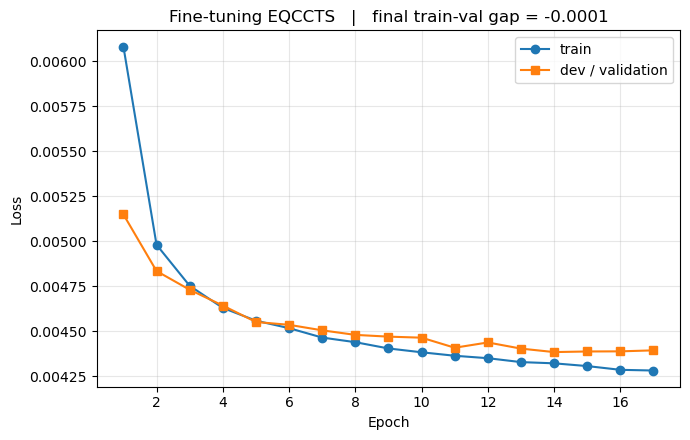

[OK] No sign of overfitting (best dev at epoch 14/17, final gap -0.0001).
saved eqccts_ft.pt


In [5]:
for cls_name, ph, col in SPECS:
    print(f"\n===== {cls_name}  (phase {ph}) =====")
    model = getattr(sbm, cls_name).from_pretrained(PRETRAINED).to(tu.DEVICE)
    base_ckpt = tu.MODELS_DIR / f"{cls_name.lower()}_baseline_{PRETRAINED}.pt"
    torch.save(model.state_dict(), base_ckpt)

    tl = DataLoader(make_gen(train, col, ph), batch_size=BATCH_SIZE, shuffle=True,
                    num_workers=0, drop_last=True)
    dl = DataLoader(make_gen(dev, col, ph), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    _b = next(iter(tl))
    print("X:", tuple(_b["X"].shape), " y:", tuple(_b["y"].shape))

    hist, best, best_ep, reason = tu.fit(model, tl, dl, loss_fn, epochs=EPOCHS,
                                         patience=PATIENCE, min_delta=MIN_DELTA, lr=LR)
    tu.plot_loss(hist, cls_name)
    torch.save(model.state_dict(), tu.MODELS_DIR / f"{cls_name.lower()}_ft.pt")
    print(f"saved {cls_name.lower()}_ft.pt")